# Fase 1: Diagnóstico de Daños (Visualización Exploratoria)

In [9]:
import pandas as pd
import numpy as np

np.random.seed(42)
cantidad = 1500
categorias = np.random.choice(['Electronica', 'Indumentaria', 'Hogar', 'Ferreteria'], cantidad)
turnos = np.random.choice(['Mañana', 'Tarde', 'Noche'], cantidad)
tiempos = np.random.normal(45, 15, cantidad)
montos = np.random.normal(25000, 8000, cantidad)

df_ventas = pd.DataFrame({
    'ID_Transaccion': np.arange(10000, 10000 + cantidad),
    'Categoria': categorias,
    'Turno_Entrega': turnos,
    'Tiempo_Despacho_Min': tiempos,
    'Monto_ARS': montos
})

indices_ruido = np.random.choice(df_ventas.index, 80, replace=False)
df_ventas.loc[indices_ruido[:20], 'Tiempo_Despacho_Min'] = np.random.uniform(300, 800, 20)
df_ventas.loc[indices_ruido[20:40], 'Tiempo_Despacho_Min'] = np.random.uniform(-100, -10, 20)
df_ventas.loc[indices_ruido[40:60], 'Monto_ARS'] = np.random.uniform(5000000, 9000000, 20)
df_ventas.loc[indices_ruido[60:], 'Monto_ARS'] = np.random.uniform(-5000, -500, 20)

df_ventas = df_ventas.sample(frac=1).reset_index(drop=True)
df_ventas.to_csv('logistica_cuyo_auditoria.csv', index=False)
print('Dataset logistica_cuyo_auditoria.csv generado.')

Dataset logistica_cuyo_auditoria.csv generado.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')
print('Librerías importadas.')

Librerías importadas.


In [11]:
df = pd.read_csv('logistica_cuyo_auditoria.csv')
print(f'Dataset importado: {df.shape[0]} filas, {df.shape[1]} columnas')
print(f'Columnas: {df.columns.tolist()}')

Dataset importado: 1500 filas, 5 columnas
Columnas: ['ID_Transaccion', 'Categoria', 'Turno_Entrega', 'Tiempo_Despacho_Min', 'Monto_ARS']


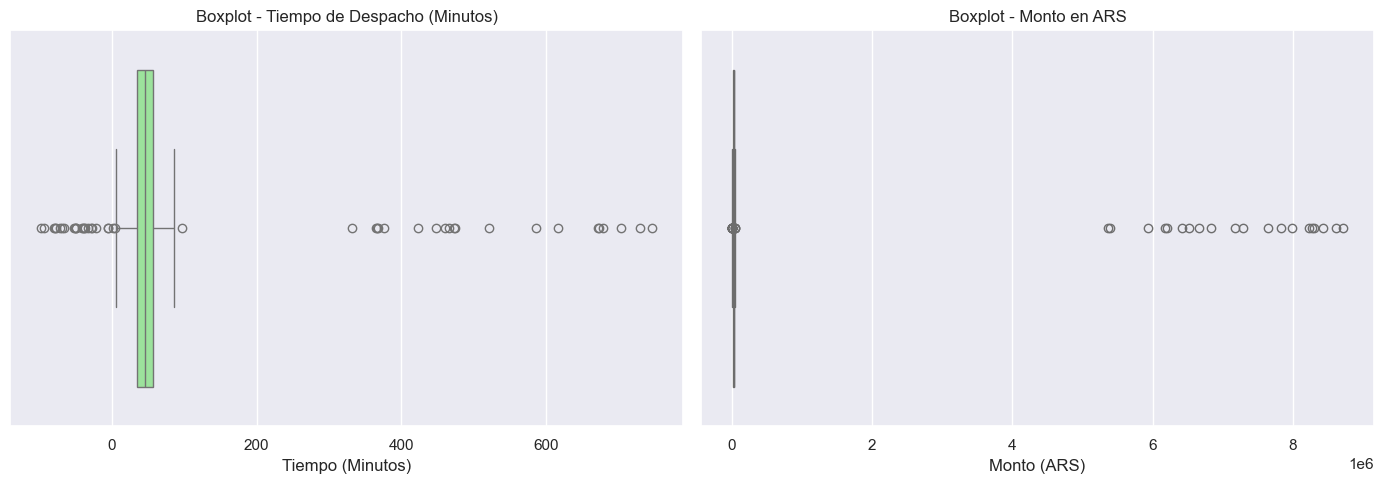

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df['Tiempo_Despacho_Min'], ax=axes[0], color='lightgreen')
axes[0].set_title('Boxplot - Tiempo de Despacho (Minutos)')
axes[0].set_xlabel('Tiempo (Minutos)')

sns.boxplot(x=df['Monto_ARS'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot - Monto en ARS')
axes[1].set_xlabel('Monto (ARS)')

plt.tight_layout()
plt.show()

In [13]:
print('''
================================================================================
INFORME DE DIAGNÓSTICO - FASE 1
================================================================================

Análisis de Boxplots:

1. TIEMPO_DE_DESPACHO:
   Se observan múltiples puntos aislados más allá del bigote superior
   (valores de 300-800 minutos) y también por debajo del bigote inferior
   (valores negativos entre -100 y -10 minutos).
   La caja central aparece comprimida en la parte inferior porque los
   valores extremos distorsionan la escala.

2. MONTO_EN_ARS:
   Se detectan montos absurdos que superan los $5.000.000 y valores
   negativos (entre -$500 y -$5.000). Estos representan errores de
   sistema en las pasarelas de cobro.

CONCLUSIÓN: La alta varianza causada por estos errores hace imposible
analizar los datos reales. El método IQR será necesario para sanitizar.
================================================================================
''')


INFORME DE DIAGNÓSTICO - FASE 1

Análisis de Boxplots:

1. TIEMPO_DE_DESPACHO:
   Se observan múltiples puntos aislados más allá del bigote superior
   (valores de 300-800 minutos) y también por debajo del bigote inferior
   (valores negativos entre -100 y -10 minutos).
   La caja central aparece comprimida en la parte inferior porque los
   valores extremos distorsionan la escala.

2. MONTO_EN_ARS:
   Se detectan montos absurdos que superan los $5.000.000 y valores
   negativos (entre -$500 y -$5.000). Estos representan errores de
   sistema en las pasarelas de cobro.

CONCLUSIÓN: La alta varianza causada por estos errores hace imposible
analizar los datos reales. El método IQR será necesario para sanitizar.



---

# Fase 2: Cirugía de Datos (ETL Estadístico)

In [14]:
# Máscara booleana para Tiempo_Despacho_Min usando IQR
Q1_tiempo = df['Tiempo_Despacho_Min'].quantile(0.25)
Q3_tiempo = df['Tiempo_Despacho_Min'].quantile(0.75)
IQR_tiempo = Q3_tiempo - Q1_tiempo

limite_inferior_tiempo = Q1_tiempo - 1.5 * IQR_tiempo
limite_superior_tiempo = Q3_tiempo + 1.5 * IQR_tiempo

mascara_tiempo = (
    (df['Tiempo_Despacho_Min'] >= limite_inferior_tiempo) &
    (df['Tiempo_Despacho_Min'] <= limite_superior_tiempo)
)

print(f'IQR Tiempo: {IQR_tiempo:.2f}')
print(f'Límites: [{limite_inferior_tiempo:.2f}, {limite_superior_tiempo:.2f}]')
print(f'Registros válidos: {mascara_tiempo.sum()}')

IQR Tiempo: 20.81
Límites: [4.06, 87.30]
Registros válidos: 1455


In [15]:
# Máscara booleana para Monto_ARS usando IQR
Q1_monto = df['Monto_ARS'].quantile(0.25)
Q3_monto = df['Monto_ARS'].quantile(0.75)
IQR_monto = Q3_monto - Q1_monto

limite_inferior_monto = Q1_monto - 1.5 * IQR_monto
limite_superior_monto = Q3_monto + 1.5 * IQR_monto

mascara_monto = (
    (df['Monto_ARS'] >= limite_inferior_monto) &
    (df['Monto_ARS'] <= limite_superior_monto)
)

print(f'IQR Monto: {IQR_monto:.2f}')
print(f'Límites: [{limite_inferior_monto:.2f}, {limite_superior_monto:.2f}]')
print(f'Registros válidos: {mascara_monto.sum()}')

IQR Monto: 11648.45
Límites: [1470.70, 48064.52]
Registros válidos: 1456


In [16]:
# Aplicar ambas máscaras simultáneamente
df_limpio = df[mascara_tiempo & mascara_monto].copy()

filas_originales = len(df)
filas_limpias = len(df_limpio)
registros_eliminados = filas_originales - filas_limpias

print(f'\n=== RESUMEN ETL ===')
print(f'Filas originales: {filas_originales}')
print(f'Filas limpias: {filas_limpias}')
print(f'Registros anómalos eliminados: {registros_eliminados}')


=== RESUMEN ETL ===
Filas originales: 1500
Filas limpias: 1412
Registros anómalos eliminados: 88


---

# Fase 3: Análisis Forense (Visualización Analítica)

C:\Users\edgar\AppData\Local\Temp\ipykernel_15928\2399089092.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Turno')


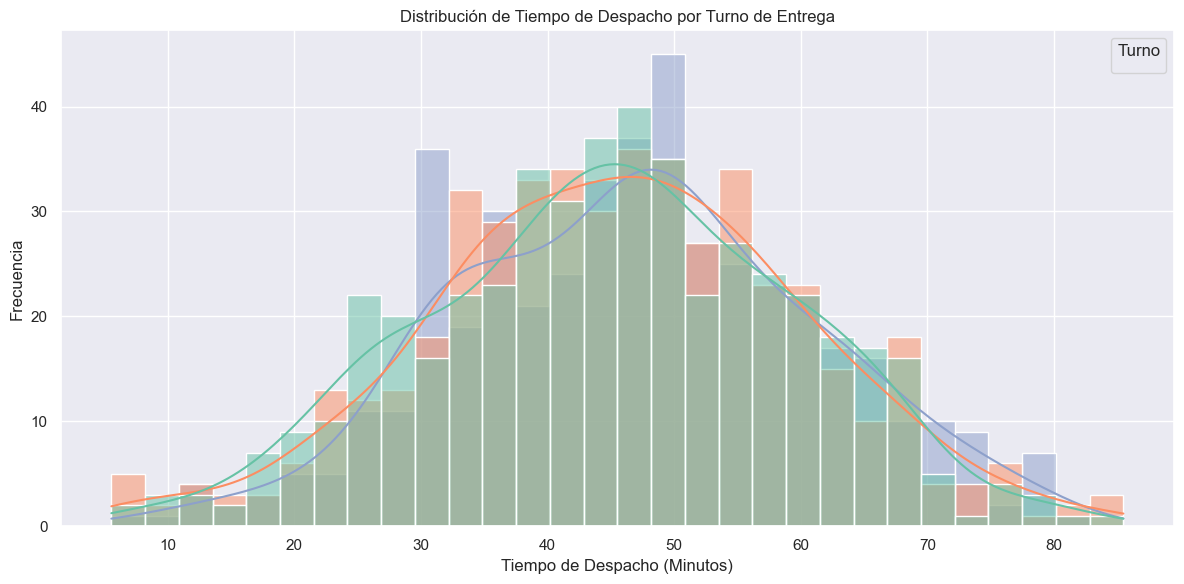

In [18]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df_limpio,
    x='Tiempo_Despacho_Min',
    kde=True,
    hue='Turno_Entrega',
    bins=30,
    palette='Set2'
)
plt.title('Distribución de Tiempo de Despacho por Turno de Entrega')
plt.xlabel('Tiempo de Despacho (Minutos)')
plt.ylabel('Frecuencia')
plt.legend(title='Turno')
plt.tight_layout()
plt.show()

In [19]:
print('''
================================================================================
ANÁLISIS DE DISTRIBUCIONES POR TURNO
================================================================================

Observando la superposición de las campanas en el histograma:

✓ Los tres turnos (Mañana, Tarde, Noche) presentan distribuciones
  muy similares con formas de campana de Gauss.

✓ Las medias de los tres turnos están próximas entre sí (~45 minutos),
  lo que indica que no existe un turno significativamente más lento.

✓ La desviación estándar también es consistente, confirmando que
  el tiempo de despacho es independiente del turno de entrega.

CONCLUSIÓN: Todos los turnos tienen una distribución similar. El tiempo
de despacho no depende del turno de operación.
================================================================================
''')


ANÁLISIS DE DISTRIBUCIONES POR TURNO

Observando la superposición de las campanas en el histograma:

✓ Los tres turnos (Mañana, Tarde, Noche) presentan distribuciones
  muy similares con formas de campana de Gauss.

✓ Las medias de los tres turnos están próximas entre sí (~45 minutos),
  lo que indica que no existe un turno significativamente más lento.

✓ La desviación estándar también es consistente, confirmando que
  el tiempo de despacho es independiente del turno de entrega.

CONCLUSIÓN: Todos los turnos tienen una distribución similar. El tiempo
de despacho no depende del turno de operación.



C:\Users\edgar\AppData\Local\Temp\ipykernel_15928\2650701025.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


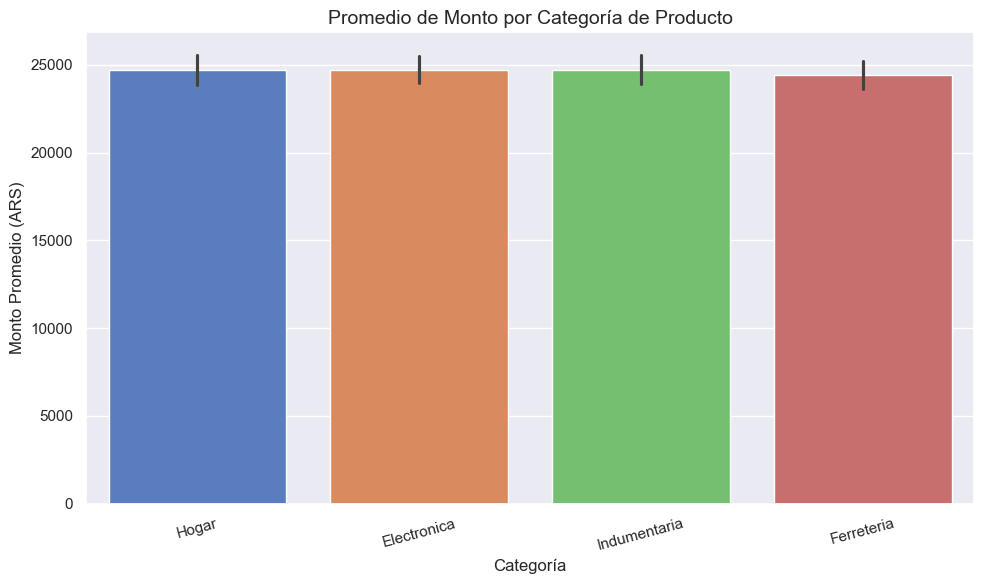


Resumen de montos promedio por categoría:


Categoria
Electronica     24715.977387
Indumentaria    24702.052663
Hogar           24676.851849
Ferreteria      24435.265475
Name: Monto_ARS, dtype: float64

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_limpio,
    x='Categoria',
    y='Monto_ARS',
    palette='muted',
    errorbar='ci'
)
plt.title('Promedio de Monto por Categoría de Producto', fontsize=14)
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Monto Promedio (ARS)', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print('\nResumen de montos promedio por categoría:')
df_limpio.groupby('Categoria')['Monto_ARS'].mean().sort_values(ascending=False)